# Testing Sparse Auto Encoder (SAE)

In principal, it should be possible to extract hidden feature vectors from embedding outputs using a sparse auto-encoder (SAE) to disentangle the superimposed features for a given set of neural activation outputs. To test the validity of using a SAE for this purpose, the code below trains one on some randomized vectors to assess whether the methods described in literature are enough to create sparsity in the feature layer of a 2-layer autoencoder.

*Note - This notebook was originally run on a gcloud instance with 32GB of memory. If you intend to re-run this notebook you will need similar compute and memory availability to avoid kernel crashes*

In [1]:
# imports
import tensorflow as tf
import keras
from keras import layers
import numpy as np
import pandas as pd
import Bio
import transformers
from objects.autoencoder import SparseAutoEncoder
import os

# data vis packages
import seaborn as sns
import matplotlib.pyplot as plt

2024-11-15 02:46:16.441864: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1731638776.713749     791 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1731638776.791422     791 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-15 02:46:17.496865: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Train the Model

In [2]:
# create dataset from random tensors to test
SAE_name = 'autoencoder_test'
embed_length = 2048
ef = 4

print("=== Generating Test Data ===")
fake_embeddings = tf.random.uniform(shape=[10000, embed_length])
fake_dataset = tf.data.Dataset.from_tensor_slices((fake_embeddings, fake_embeddings)).batch(100)

print("=== Initializing Model ===")
# initialize the optimizer
optimizer = keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.98,
                                     epsilon=1e-9)

# initialize the loss function
loss = keras.losses.MeanSquaredError()

# initialize the metrics
metrics = [
    keras.metrics.MeanSquaredError(),
    keras.metrics.KLDivergence(),
]

# compile the model
autoencoder = SparseAutoEncoder(encoding_size=embed_length, expansion_factor=ef)
autoencoder.compile(optimizer=optimizer, loss=loss, metrics=metrics)

print(autoencoder.summary())

tb_callback = keras.callbacks.TensorBoard(log_dir=f'./logs/{SAE_name}', histogram_freq=5)
early_stopping = keras.callbacks.EarlyStopping(
    monitor='mean_squared_error',
    min_delta=0.001,
    patience=10, 
    restore_best_weights=True
    )

print("=== Training Model ===")
history = autoencoder.fit(fake_dataset, epochs=100, callbacks=[tb_callback, early_stopping])
print("=== Saving Model ===")
path = f'./models/{SAE_name}.keras'
#autoencoder.save(f'./models/{SAE_name}.keras')
keras.models.save_model(autoencoder, path)
print(f"Model saved to: {path}")
print(autoencoder.summary())

=== Generating Test Data ===
=== Initializing Model ===


2024-11-15 01:00:52.195348: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sparse_auto_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

 Total params: 100,700,162 (384.14 MB)

 Trainable params: 33,566,720 (128.05 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 67,133,442 (256.09 MB)

None


### Examine Weights and their Distribution

Note that in a real use case we would expect most features to have relatively low weights (roughly corresponding to the feature's importance), however, in this case we observe a somewhat sine-like distribution with a bit of decay. I suspect this is due to the process of random number generation, but further analysis would be warranted before asserting that claim.

As a note to myself, the concept of superposition shares a lot of common principles with slit experiments and waves so this particular graph might actually warrant some further investigation from a purely mathematical standpoint. 

In [3]:
feat_weights = np.array(autoencoder.weights[2])
print(f"maximum: {max(feat_weights)}")
print(f"minimum: {min(feat_weights)}")

maximum: -0.025521650910377502
minimum: -0.24063000082969666


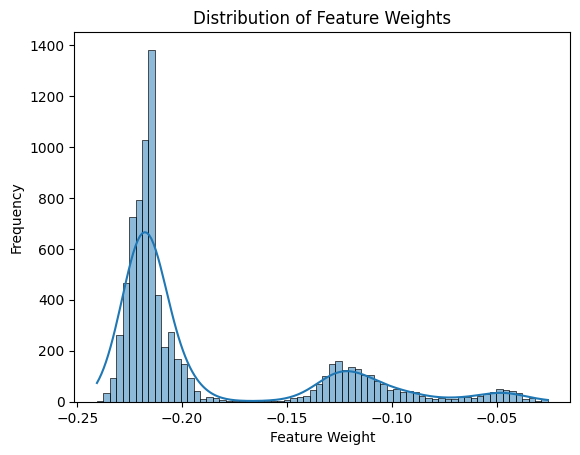

In [4]:
sns.histplot(feat_weights, kde=True)
plt.title('Distribution of Feature Weights')
plt.xlabel('Feature Weight')
plt.ylabel('Frequency')
plt.show()

### Examining Feature Layer for Sparsity

In [5]:
autoencoder.predict_on_batch(fake_embeddings[:100])

(array([[0.4786815 , 0.4897106 , 0.5329211 , ..., 0.5517175 , 0.53292847,
         0.49938992],
        [0.47769508, 0.4892189 , 0.530432  , ..., 0.5486119 , 0.5306477 ,
         0.49834466],
        [0.47397748, 0.48540306, 0.5244982 , ..., 0.5433022 , 0.52519655,
         0.49318433],
        ...,
        [0.47368523, 0.48365825, 0.5221942 , ..., 0.5398572 , 0.52269304,
         0.4924873 ],
        [0.47060242, 0.47968593, 0.51526505, ..., 0.5319181 , 0.51550543,
         0.48811668],
        [0.4715185 , 0.48124418, 0.5176494 , ..., 0.53416455, 0.5181877 ,
         0.48965767]], dtype=float32),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32))

In [6]:
reconstructed_outputs, feature_outputs = autoencoder.predict_on_batch(fake_embeddings[:100])

In [7]:
reconstructed_outputs

array([[0.4786815 , 0.4897106 , 0.5329211 , ..., 0.5517175 , 0.53292847,
        0.49938992],
       [0.47769508, 0.4892189 , 0.530432  , ..., 0.5486119 , 0.5306477 ,
        0.49834466],
       [0.47397748, 0.48540306, 0.5244982 , ..., 0.5433022 , 0.52519655,
        0.49318433],
       ...,
       [0.47368523, 0.48365825, 0.5221942 , ..., 0.5398572 , 0.52269304,
        0.4924873 ],
       [0.47060242, 0.47968593, 0.51526505, ..., 0.5319181 , 0.51550543,
        0.48811668],
       [0.4715185 , 0.48124418, 0.5176494 , ..., 0.53416455, 0.5181877 ,
        0.48965767]], dtype=float32)

In [8]:
feature_outputs

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [9]:
feature_outputs[0].sort()
print(feature_outputs[0][-20:])
print(feature_outputs.shape)

[0.06943753 0.06988491 0.06996618 0.07041478 0.07052432 0.07053104
 0.0708085  0.07114303 0.07129343 0.07135776 0.07168376 0.07178286
 0.07273011 0.07398552 0.07411599 0.07685027 0.07716194 0.07872409
 0.07980262 0.08375813]
(100, 8192)


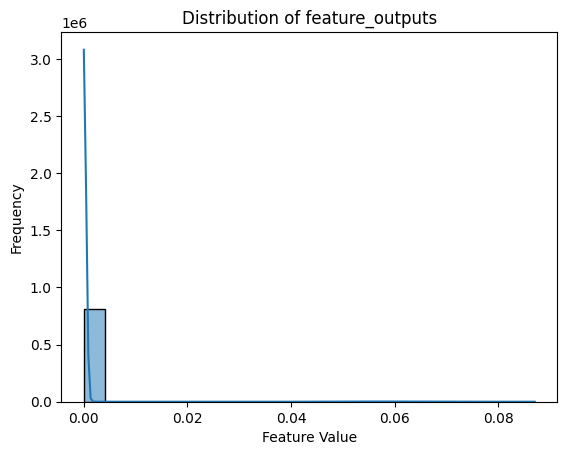

In [10]:
sns.histplot(feature_outputs.flatten(), kde=True)
plt.title('Distribution of feature_outputs')
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
plt.show()

### Check Model Fit / Overfit

In [11]:
# check model fit
fit_test_data = tf.random.uniform(shape=[100, embed_length])
fit_test_dataset = tf.data.Dataset.from_tensor_slices((fit_test_data, fit_test_data)).batch(10)

fit_test = autoencoder.evaluate(fit_test_dataset)
print(f"Loss: {fit_test[0]} | MSE: {fit_test[1]}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 184.8672 - mean_squared_error: 0.0842
Loss: 184.86204528808594 | MSE: 0.08428828418254852
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 184.8672 - mean_squared_error: 0.0842
Loss: 184.86204528808594 | MSE: 0.08428828418254852


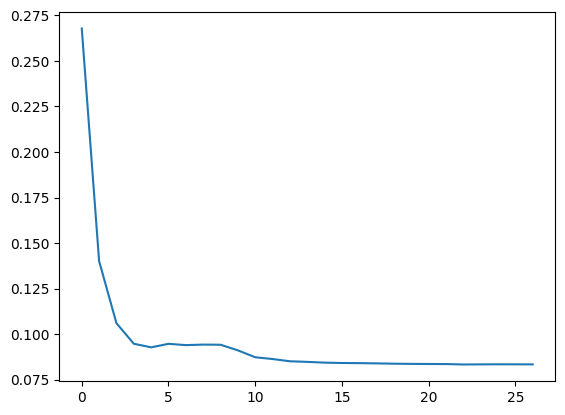

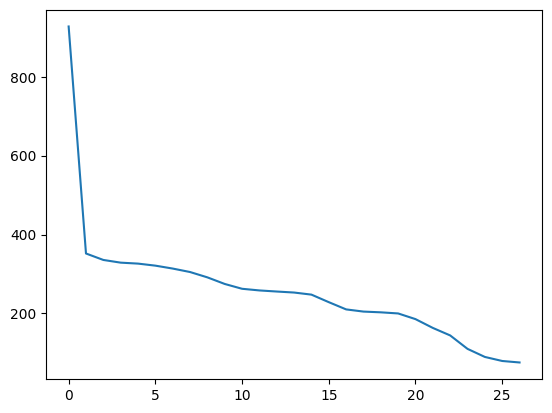

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history['mean_squared_error'])
plt.show()
plt.plot(history.history['loss'])
plt.show()

In [ ]:
# cleaning some memory
del fake_embeddings
del fake_dataset
del feat_weights
del reconstructed_outputs, feature_outputs, fit_test, fit_test_data, fit_test_dataset
del autoencoder, loss, metrics, optimizer, SAE_name, embed_length, ef, tb_callback, early_stopping, history, path

# SAE on ESM Embeddings for Hemoglobin Variants

Using the embeddings we previously generated from ESM-2, we're going to extract per-residue features based on the superposition hypothesis. After a bit of reformatting the data for this purpose, we should be able to train it to decompose the 1280-dimensional embeddings into a given number of features (number of neurons in the feature/2nd layer). The weights approximate the importance of those features.

In [2]:
# load metadata
var_data = pd.read_csv('./data/hbvar-w-func-embed-seq.csv')
# pandas saves these as strings for some reason - reload from numpy
var_data.drop(columns=['embeddings', 'sequence_representation', 'esm_representation'], inplace=True)
# drop stuff we don't need right now
var_data.drop(columns=[
    'electrophoresisComment',
    'hgvsName',
    'chromatography',
    'dnaDescriptionComment',
    'aliases',
    'stability',
    'functionalComment',
    'variantComment',
    'Structure',
    'electrophoresis',
    'name'
    ],
    inplace=True
)

# explicitly match embeddings to sequences when re-loading
embeddings = [np.load(f"./data/variant_embeddings/all_vars/{j}.npy") for j in var_data["sequence"]]

# reduce jagged tensors and add to dataframe
def fix_jagged_2d(embed_list):
    sir_gallahad_the_chaste = []
    # find max length in 2nd dim (sequence length)
    max_len = max([len(arr[0]) for arr in embed_list])
    # append zero vector to embeddings
    for i, arr in enumerate(embed_list):
        if len(arr[0]) < max_len:
            padded = np.append(arr[0], np.zeros((max_len - len(arr[0]), 1280)), axis=0)
            sir_gallahad_the_chaste.append(np.expand_dims(padded, axis=0))
        else:
            sir_gallahad_the_chaste.append(arr)
    return sir_gallahad_the_chaste

embeddings = np.concatenate(fix_jagged_2d(embeddings))
var_data['embeddings'] = embeddings
print(embeddings.shape)

(1206, 148, 1280)


In [3]:
# create dataset for training SAE
def pad_sequences(amino_acid_seq:str, pad_length:int):
    if len(amino_acid_seq)==pad_length:
        return amino_acid_seq
    else:
        return amino_acid_seq+''.join(['-' for i in range(pad_length-len(amino_acid_seq))])

residue_embeddings = np.vstack(embeddings)
residue_labels = ''.join([pad_sequences(i, 148) for i in var_data['sequence']])
print(residue_embeddings.shape)
print(len(residue_labels))

(178488, 1280)
178488


In [17]:
embed_data = pd.DataFrame(residue_embeddings)
embed_data["residues"] = [i for i in residue_labels]
ids = []
for x in var_data['sequence']:
    for n in range(148):
        ids.append(x)
embed_data["id"] = ids
embed_data

,0,1,2,3,4,5,6,7,8,9,...,1272,1273,1274,1275,1276,1277,1278,1279,residues,id
0,0.039880,-0.060474,0.010107,0.036829,-0.108196,0.034697,0.064647,-0.159625,-0.046258,0.062892,...,-0.141350,0.002107,0.019046,-0.125863,-0.041022,-0.254396,0.179195,0.026323,M,MGLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPH...
1,0.080393,-0.052154,-0.171746,0.341434,0.078772,-0.058304,0.333229,-0.171261,-0.152863,0.206985,...,0.022498,0.101823,-0.029865,0.270576,-0.352361,0.134863,-0.125038,0.054623,G,MGLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPH...
2,-0.049513,0.014455,-0.113939,0.060111,-0.072646,-0.010627,0.273609,-0.318852,0.433905,0.061857,...,0.014927,0.150102,-0.240294,0.024542,0.329014,0.054479,0.119776,-0.048153,L,MGLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPH...
3,0.127423,-0.091589,0.235782,0.205985,0.035046,0.042871,0.346926,-0.112454,-0.497411,0.014614,...,-0.036321,0.142612,0.149523,-0.274964,0.304388,-0.278865,0.117745,-0.125761,S,MGLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPH...
4,-0.008895,-0.026455,-0.074877,0.359108,-0.062585,0.190984,0.031155,-0.140788,-0.187589,0.197234,...,0.101468,-0.070155,-0.134162,-0.248186,-0.223817,0.005409,-0.130158,-0.222160,P,MGLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPH...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178483,-0.012570,0.155609,0.086157,0.203023,-0.189751,-0.219611,-0.089043,0.141252,-0.281113,0.286330,...,0.209440,-0.015287,-0.029175,0.007206,-0.113142,-0.114191,-0.199395,-0.126701,S,MGHFTEEDKATITSLWGKVNVEHAGGETLGRLLVVYPWTQRFFDSF...
178484,0.157495,0.253602,0.138182,0.164223,-0.114125,0.041772,-0.272245,0.024113,-0.052295,-0.014184,...,0.064878,0.118406,-0.092403,-0.098055,-0.239957,0.003924,-0.059399,-0.180254,R,MGHFTEEDKATITSLWGKVNVEHAGGETLGRLLVVYPWTQRFFDSF...
178485,0.039321,0.246502,0.044173,-0.037274,-0.029826,0.237742,-0.124555,0.027676,-0.236433,0.184976,...,0.077372,0.051368,0.180057,0.124684,-0.093465,-0.041433,0.026563,0.055376,Y,MGHFTEEDKATITSLWGKVNVEHAGGETLGRLLVVYPWTQRFFDSF...
178486,0.065609,-0.021404,-0.343105,0.312501,-0.192077,0.259709,0.161792,0.007382,-0.082263,-0.003792,...,0.114312,-0.013490,-0.047376,0.030331,-0.233131,-0.246021,-0.036705,0.138261,H,MGHFTEEDKATITSLWGKVNVEHAGGETLGRLLVVYPWTQRFFDSF...


In [18]:
# just in case we want to reload / use this later
embed_data.to_csv("./data/heme_SAE_train.csv")

### Training the SAE

In [ ]:
# cleaning some memory
del embed_data, embeddings, var_data

In [5]:
# key parameters, model name
SAE_name = 'ESM-2-1280d-SAE-ef4'
embed_length = 1280
ef = 4

print("=== Initializing Model ===")
# initialize the optimizer
optimizer = keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.98,
                                     epsilon=1e-9)

# initialize the loss function
loss = keras.losses.MeanSquaredError()

# initialize the metrics
metrics = [
    keras.metrics.MeanSquaredError(),
    keras.metrics.KLDivergence(), # training requires a placeholder metric for the feature ouputs in the forward call
]

# compile the model
autoencoder = SparseAutoEncoder(encoding_size=embed_length, expansion_factor=ef)
autoencoder.compile(optimizer=optimizer, loss=loss, metrics=metrics)

print(autoencoder.summary())

tb_callback = keras.callbacks.TensorBoard(log_dir=f'./logs/{SAE_name}', histogram_freq=5)
early_stopping = keras.callbacks.EarlyStopping(
    monitor='loss',
    min_delta=0.001,
    patience=10, 
    restore_best_weights=True
    )

print("=== Training Model ===")
history = autoencoder.fit(
    x=residue_embeddings,
    y=residue_embeddings,
    batch_size=32, 
    epochs=100, 
    validation_split=0.1, 
    callbacks=[tb_callback, early_stopping]
    )
print("=== Saving Model ===")
path = f'./models/{SAE_name}.keras'
#autoencoder.save(f'./models/{SAE_name}.keras')
keras.models.save_model(autoencoder, path)
print(f"Model saved to: {path}")
print(autoencoder.summary())

=== Initializing Model ===


2024-11-15 02:48:06.927636: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sparse_auto_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
=== Training Model ===
Epoch 1/100


/home/user/anaconda3/envs/hsg/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:731: UserWarning: Gradients do not exist for variables ['variable'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


3781/5020 ━━━━━━━━━━━━━━━━━━━━ 1:37 79ms/step - loss: 33.9090 - mean_squared_error: 0.0706

In [ ]:
import matplotlib.pyplot as plt

print("===== MSE =====")
plt.plot(history.history['mean_squared_error'])
plt.plot(history.history['val_mean_squared_error'])
plt.show()

print("===== LOSS =====")
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()